# Actividad 1: Análisis y preprocesamiento de datos de Nestor Fernandez

En este notebook se realizara el análisis exploratorio, limpieza y preprocesamiento de un dataset de estaciones de servicio y precios de combustible que tenemos en nuestro csv para poder realizar esta practica.

In [20]:
!python -m pip install autoviz

  Using cached autoviz-0.1.905-py3-none-any.whl.metadata (14 kB)
  Using cached xlrd-2.0.2-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached wordcloud-1.9.6-cp314-cp314-win_amd64.whl.metadata (3.5 kB)
  Using cached emoji-2.15.0-py3-none-any.whl.metadata (5.7 kB)
  Using cached pyamg-5.3.0.tar.gz (4.2 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached statsmodels-0.14.6-cp314-cp314-win_amd64.whl.metadata (9.8 kB)
  Using cached nltk-3.9.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached textblob-0.19.0-py3-none-any.whl.metadata (4.4 kB)
  Using cached xgboost-1.6.2-py3-none-win_amd64.whl.metadata (1.8 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached typi

  error: subprocess-exited-with-error
  
  × Building wheel for pyamg (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [160 lines of output]
      C:\Users\nesfe\AppData\Local\Temp\pip-build-env-xjun9ujq\overlay\Lib\site-packages\setuptools_scm\git.py:310: UserWarning: git archive did not support describe output
        warnings.warn("git archive did not support describe output")
      C:\Users\nesfe\AppData\Local\Temp\pip-build-env-xjun9ujq\overlay\Lib\site-packages\setuptools_scm\git.py:328: UserWarning: unprocessed git archival found (no export subst applied)
        warnings.warn("unprocessed git archival found (no export subst applied)")
      C:\Users\nesfe\AppData\Local\Temp\pip-build-env-xjun9ujq\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consider removing the

In [21]:
!python -m pip install pandas matplotlib scikit-learn autoviz

  Using cached autoviz-0.1.905-py3-none-any.whl.metadata (14 kB)
  Using cached xlrd-2.0.2-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached wordcloud-1.9.6-cp314-cp314-win_amd64.whl.metadata (3.5 kB)
  Using cached emoji-2.15.0-py3-none-any.whl.metadata (5.7 kB)
  Using cached pyamg-5.3.0.tar.gz (4.2 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached statsmodels-0.14.6-cp314-cp314-win_amd64.whl.metadata (9.8 kB)
  Using cached nltk-3.9.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached textblob-0.19.0-py3-none-any.whl.metadata (4.4 kB)
  Using cached xgboost-1.6.2-py3-none-win_amd64.whl.metadata (1.8 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached typi

  error: subprocess-exited-with-error
  
  × Building wheel for pyamg (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [160 lines of output]
      C:\Users\nesfe\AppData\Local\Temp\pip-build-env-6cb9y5mn\overlay\Lib\site-packages\setuptools_scm\git.py:310: UserWarning: git archive did not support describe output
        warnings.warn("git archive did not support describe output")
      C:\Users\nesfe\AppData\Local\Temp\pip-build-env-6cb9y5mn\overlay\Lib\site-packages\setuptools_scm\git.py:328: UserWarning: unprocessed git archival found (no export subst applied)
        warnings.warn("unprocessed git archival found (no export subst applied)")
      C:\Users\nesfe\AppData\Local\Temp\pip-build-env-6cb9y5mn\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consider removing the

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(
    "upbinfo30_ act1_ord (1).csv",
    sep=",",
    encoding="latin1",
    on_bad_lines="skip"
)

In [4]:
print("Dimensiones:", df.shape)
print("\nColumnas:", df.columns)

print("\nPrimeras filas:")
display(df.head())

print("\nInformación:")
df.info()

print("\nValores nulos:")
print(df.isnull().sum())

Dimensiones: (11865, 10)

Columnas: Index(['Provincia', 'Municipio', 'Localidad', 'CÃ³digo postal', 'DirecciÃ³n',
       'Precio gasolina 95 E5', 'Precio gasÃ³leo A', 'Tipo venta',
       'Tipo servicio', 'RÃ³tulo'],
      dtype='str')

Primeras filas:


,Provincia,Municipio,Localidad,CÃ³digo postal,DirecciÃ³n,Precio gasolina 95 E5,Precio gasÃ³leo A,Tipo venta,Tipo servicio,RÃ³tulo
0,ALBACETE,ABENGIBRE,ABENGIBRE,2250,"AVENIDA CASTILLA LA MANCHA, 26","1,529","1,419",P,A,NÂº 10.935
1,ALBACETE,ALBACETE,ALBACETE,2001,"CALLE FEDERICO GARCIA LORCA, 5",NaN,"1,560",R,A,CEPSA
2,ALBACETE,ALBACETE,ALBACETE,2001,"CALLE FEDERICO GARCIA LORCA, 1","1,409","1,399",P,D,PLENOIL
3,ALBACETE,ALBACETE,ALBACETE,2001,"AVENIDA 1Âº DE MAYO, S/N","1,539","1,489",P,A,CARREFOUR
4,ALBACETE,ALBACETE,ALBACETE,2001,CALLE PRINCIPE DE ASTURIAS (POLÃGONO DE ROMIC...,"1,549","1,549",P,A,BP ROMICA



Información:
<class 'pandas.DataFrame'>
RangeIndex: 11865 entries, 0 to 11864
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Provincia              11865 non-null  str  
 1   Municipio              11865 non-null  str  
 2   Localidad              11865 non-null  str  
 3   CÃ³digo postal         11865 non-null  int64
 4   DirecciÃ³n             11865 non-null  str  
 5   Precio gasolina 95 E5  10702 non-null  str  
 6   Precio gasÃ³leo A      11498 non-null  str  
 7   Tipo venta             11865 non-null  str  
 8   Tipo servicio          10803 non-null  str  
 9   RÃ³tulo                11865 non-null  str  
dtypes: int64(1), str(9)
memory usage: 927.1 KB

Valores nulos:
Provincia                   0
Municipio                   0
Localidad                   0
CÃ³digo postal              0
DirecciÃ³n                  0
Precio gasolina 95 E5    1163
Precio gasÃ³leo A         367
Tipo venta    

In [5]:
df.columns = [
    "Provincia",
    "Municipio",
    "Localidad",
    "Codigo_postal",
    "Direccion",
    "Precio_gasolina",
    "Precio_gasoleo",
    "Tipo_venta",
    "Tipo_servicio",
    "Rotulo"
]

In [6]:
df["Precio_gasolina"] = df["Precio_gasolina"].astype(str).str.replace(",", ".", regex=False)
df["Precio_gasoleo"] = df["Precio_gasoleo"].astype(str).str.replace(",", ".", regex=False)

In [7]:
df["Precio_gasolina"] = pd.to_numeric(df["Precio_gasolina"], errors="coerce")
df["Precio_gasoleo"] = pd.to_numeric(df["Precio_gasoleo"], errors="coerce")

In [8]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

df["Precio_gasolina"] = imputer.fit_transform(df[["Precio_gasolina"]]).ravel()
df["Precio_gasoleo"] = imputer.fit_transform(df[["Precio_gasoleo"]]).ravel()

In [9]:
df.isnull().sum()

Provincia             0
Municipio             0
Localidad             0
Codigo_postal         0
Direccion             0
Precio_gasolina       0
Precio_gasoleo        0
Tipo_venta            0
Tipo_servicio      1062
Rotulo                0
dtype: int64

In [10]:
df[["Precio_gasolina", "Precio_gasoleo"]].describe()

,Precio_gasolina,Precio_gasoleo
count,11865.000000,11865.000000
mean,1.532225,1.480451
std,0.092902,0.106250
min,1.037000,1.037000
25%,1.485000,1.399000
50%,1.549000,1.519000
75%,1.599000,1.568000
max,2.299000,2.259000


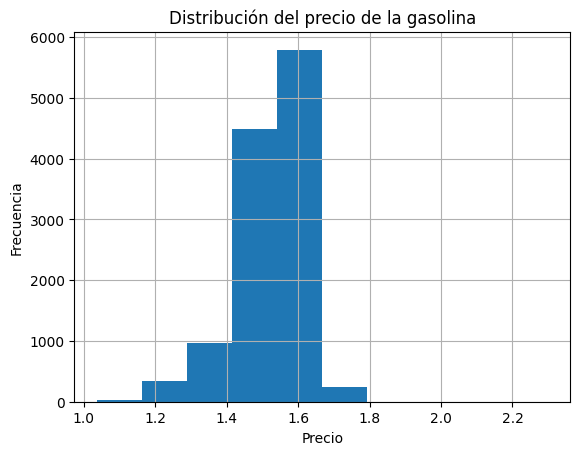

In [11]:
df["Precio_gasolina"].hist()
plt.title("Distribución del precio de la gasolina")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

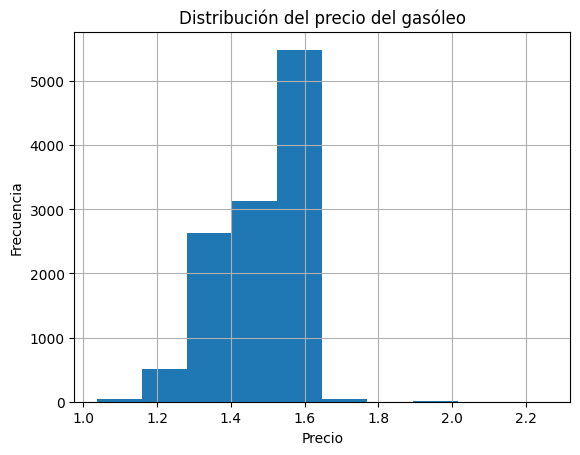

In [12]:
df["Precio_gasoleo"].hist()
plt.title("Distribución del precio del gasóleo")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

In [13]:
df_madrid = df[df["Provincia"] == "MADRID"]

print("Número de estaciones en Madrid:", df_madrid.shape[0])
df_madrid.head()

Número de estaciones en Madrid: 852


,Provincia,Municipio,Localidad,Codigo_postal,Direccion,Precio_gasolina,Precio_gasoleo,Tipo_venta,Tipo_servicio,Rotulo
6484,MADRID,AJALVIR,AJALVIR,28864,CARRETERA M-114 KM. 1,1.599,1.579,P,A,REPSOL
6485,MADRID,AJALVIR,AJALVIR,28864,"CARRETERA M-114 KM. 0,7",1.599,1.579,P,A,REPSOL
6486,MADRID,AJALVIR,AJALVIR,28864,"CAMINO TORREJON, 4",1.479,1.389,P,D,PLENOIL
6487,MADRID,ÃLAMO (EL),ALAMO (EL),28607,"CTRA. LOCAL M-404 km 3,640",1.464,1.339,P,A,"E.S. EL ALAMO, S.L."
6488,MADRID,ÃLAMO (EL),ALAMO (EL),28607,"AVENIDA MADRID, 2",1.459,1.349,P,D,PLENOIL


In [14]:
df[["Precio_gasolina", "Precio_gasoleo"]].corr()

,Precio_gasolina,Precio_gasoleo
Precio_gasolina,1.000000,0.877961
Precio_gasoleo,0.877961,1.000000


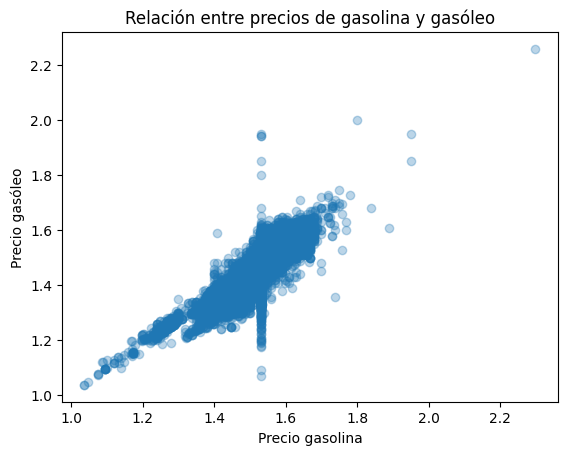

In [16]:
import matplotlib.pyplot as plt

plt.scatter(df["Precio_gasolina"], df["Precio_gasoleo"], alpha=0.3)
plt.xlabel("Precio gasolina")
plt.ylabel("Precio gasóleo")
plt.title("Relación entre precios de gasolina y gasóleo")

plt.savefig("relacion_precios.png")
plt.show()

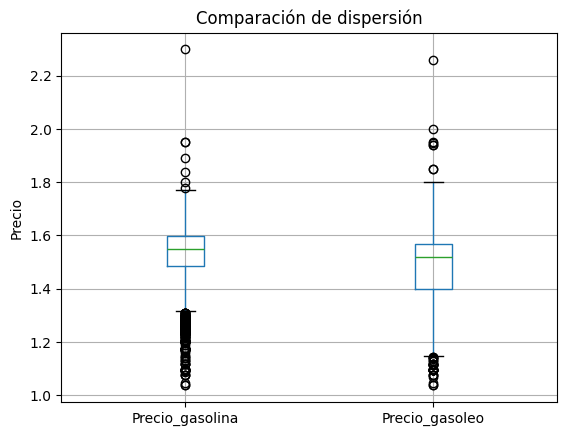

In [17]:
import matplotlib.pyplot as plt

df[["Precio_gasolina", "Precio_gasoleo"]].boxplot()
plt.title("Comparación de dispersión")
plt.ylabel("Precio")

plt.savefig("boxplot_precios.png")
plt.show()

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["Precio_gasolina_norm", "Precio_gasoleo_norm"]] = scaler.fit_transform(
    df[["Precio_gasolina", "Precio_gasoleo"]]
)

df.head()

,Provincia,Municipio,Localidad,Codigo_postal,Direccion,Precio_gasolina,Precio_gasoleo,Tipo_venta,Tipo_servicio,Rotulo,Precio_gasolina_norm,Precio_gasoleo_norm
0,ALBACETE,ABENGIBRE,ABENGIBRE,2250,"AVENIDA CASTILLA LA MANCHA, 26",1.529000,1.419,P,A,NÂº 10.935,-3.472060e-02,-0.578382
1,ALBACETE,ALBACETE,ALBACETE,2001,"CALLE FEDERICO GARCIA LORCA, 5",1.532225,1.560,R,A,CEPSA,-2.390199e-15,0.748729
2,ALBACETE,ALBACETE,ALBACETE,2001,"CALLE FEDERICO GARCIA LORCA, 1",1.409000,1.399,P,D,PLENOIL,-1.326461e+00,-0.766625
3,ALBACETE,ALBACETE,ALBACETE,2001,"AVENIDA 1Âº DE MAYO, S/N",1.539000,1.489,P,A,CARREFOUR,7.292441e-02,0.080467
4,ALBACETE,ALBACETE,ALBACETE,2001,CALLE PRINCIPE DE ASTURIAS (POLÃGONO DE ROMIC...,1.549000,1.549,P,A,BP ROMICA,1.805694e-01,0.645196


In [19]:
from autoviz.AutoViz_Class import AutoViz_Class

AV = AutoViz_Class()

AV.AutoViz(
    "upbinfo30_ act1_ord (1).csv",
    sep=",",
    encoding="latin1"
)

ModuleNotFoundError: No module named 'autoviz'

## Análisis con AutoViz

He intentado utilizar la librería AutoViz para realizar el análisis exploratorio automático del conjunto de datos para realizar la practica, pero no ha funcionado.

Ya que durante la instalación me han surgido problemas de compatibilidad con dependencias externas (como pyamg), que requieren herramientas de compilación adicionales (Microsoft Visual C++ Build Tools).

Debido a ello, el análisis exploratorio se ha realizado manualmente utilizando Pandas, Matplotlib y Scikit-learn, obteniendo resultados equivalentes al EDA automático.

## Propuesta de Machine Learning

Propongo un problema de regresión para predecir el precio del combustible en función de variables como la provincia, localización o tipo de servicio.

También se podría plantear un problema de clasificación para determinar si una estación tiene precios altos o bajos en comparación con la media y asi poder ver todo mas facil.